In [1]:
!pip uninstall -y dynamic-conversation dynamic_conversation
!pip cache purge  # clears cached wheels
!pip install --no-cache-dir git+https://github.com/Javin-Mendiratta/Dynamic-Conversation.git@derek_12_13

Files removed: 0
  Cloning https://github.com/Javin-Mendiratta/Dynamic-Conversation.git (to revision main) to /tmp/pip-req-build-u9fp37r7
  Running command git clone --filter=blob:none --quiet https://github.com/Javin-Mendiratta/Dynamic-Conversation.git /tmp/pip-req-build-u9fp37r7
  Resolved https://github.com/Javin-Mendiratta/Dynamic-Conversation.git to commit 37608bb30ff10b39b16601d0bb976bbe0d03788c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for dynamic-conversation: filename=dynamic_conversation-0.1.1-py3-none-any.whl size=14921 sha256=db5f885b886dd4a0dd89a05e40621b72fd70324cf4910f6f0aa411b9c5d5350d
  Stored in directory: /tmp/pip-ephem-wheel-cache-5bmebqv4/wheels/57/cd/2f/99075f7d11bcf410b468ec320f3fd004e1cfd89248cb13d2f0
Successfully built dynamic-conversation


In [2]:
from dynamic_conversation import EmotionFlowAnalyzer
from datasets import load_dataset

In [3]:

"""Execute emotion flow analysis pipeline."""

# Load dataset
print("=" * 60)
print("EMOTION FLOW ANALYSIS - ESConv Dataset")
print("=" * 60)
print("\nLoading ESConv dataset...")
dataset = load_dataset("thu-coai/esconv")
print(f"✓ Dataset loaded with {len(dataset['train'])} conversations")

# Initialize analyzer
print("\n" + "=" * 60)
analyzer = EmotionFlowAnalyzer(use_gpu=True)

# Process conversations
print("\n" + "=" * 60)
analyzer.process_dataset(dataset, max_conversations=100)

if len(analyzer.conversation_emotions) == 0:
    raise Exception("Error: No conversations were successfully processed!")
    

# Compute transition matrix
print("\n" + "=" * 60)
print("Computing emotion transition matrix...")
transition_matrix = analyzer.compute_transition_matrix()
print("\nTransition Matrix:")
print(transition_matrix.round(3))

# Compute trajectory scores
print("\n" + "=" * 60)
print("Computing emotion trajectory scores...")
trajectory_scores = analyzer.compute_all_trajectory_scores()
print("\nTrajectory Scores (first 5 conversations):")
print(trajectory_scores.head())

EMOTION FLOW ANALYSIS - ESConv Dataset

Loading ESConv dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/510 [00:00<?, ?B/s]

train.txt: 0.00B [00:00, ?B/s]

valid.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cuda:0



Processing conversations...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Classifying emotions: 100%|██████████| 100/100 [00:15<00:00,  6.35it/s]


Successfully processed 100 conversations

Computing emotion transition matrix...

Transition Matrix:
          anger  disgust   fear    joy  neutral  sadness  surprise
anger     0.085    0.043  0.050  0.099    0.433    0.206     0.085
disgust   0.051    0.137  0.111  0.068    0.325    0.197     0.111
fear      0.060    0.046  0.176  0.097    0.389    0.199     0.032
joy       0.017    0.018  0.046  0.347    0.402    0.103     0.066
neutral   0.052    0.043  0.067  0.157    0.464    0.150     0.068
sadness   0.058    0.032  0.070  0.109    0.376    0.270     0.085
surprise  0.036    0.046  0.102  0.137    0.386    0.183     0.112

Computing emotion trajectory scores...

Trajectory Scores (first 5 conversations):
   conversation_id emotion_type           problem_type  anger_trajectory  \
0                0      anxiety             job crisis          0.039545   
1                1   depression     ongoing depression          0.020815   
2                2      anxiety             job cri


Generating visualizations...



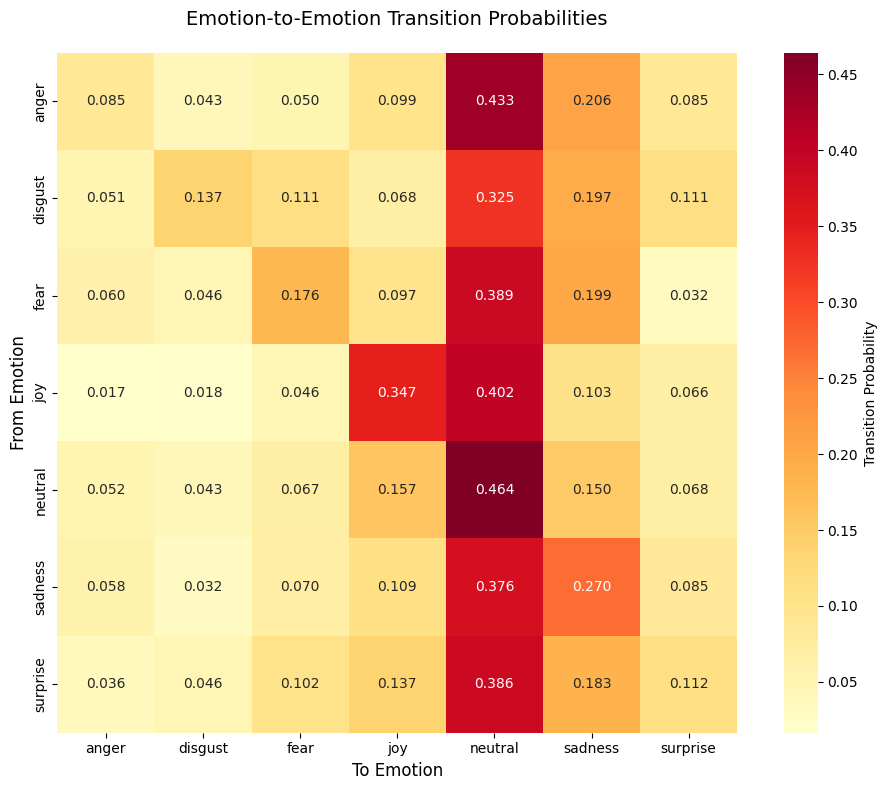

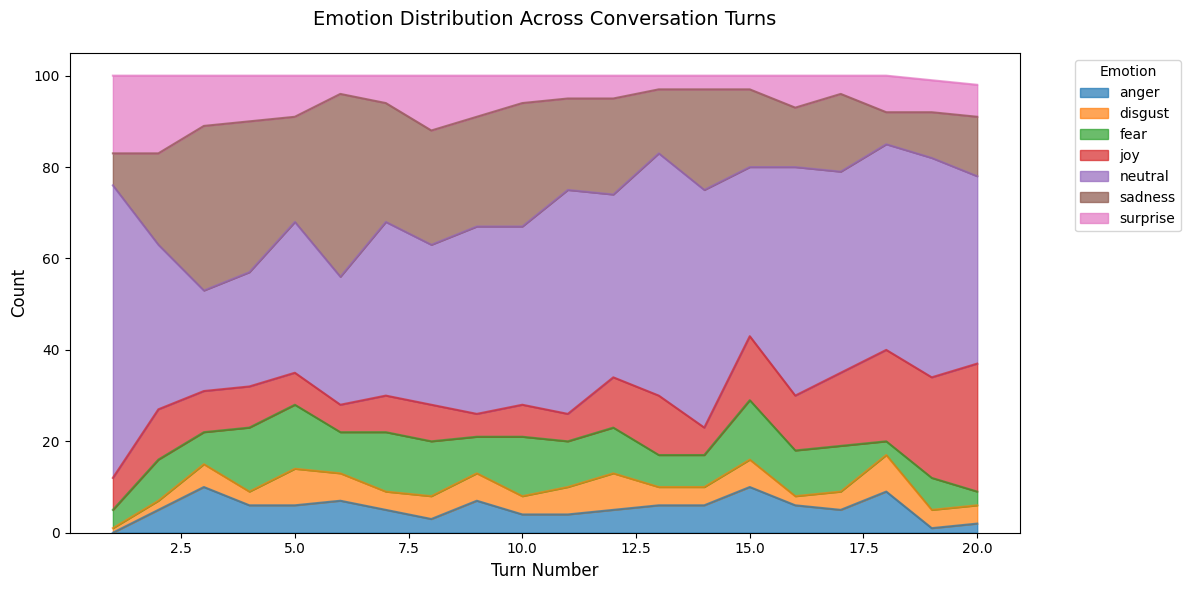


✓ ANALYSIS COMPLETE!
Processed: 100 conversations

Generated files:
  📊 emotion_transition_heatmap.png
  📈 emotion_sankey.html
  📉 aggregate_emotion_flow.png
  📄 emotion_trajectory_scores.csv


In [4]:
# Generate visualizations
print("\n" + "=" * 60)
print("Generating visualizations...")
print()

analyzer.plot_transition_heatmap(save_path=None)
analyzer.plot_sankey_diagram(save_path=None, conversation_id=0)
analyzer.plot_aggregate_emotion_flow(save_path=None)

# Summary
print("\n" + "=" * 60)
print("✓ ANALYSIS COMPLETE!")
print("=" * 60)
print(f"Processed: {len(analyzer.conversation_emotions)} conversations")
print("\nGenerated files:")
print("  📊 emotion_transition_heatmap.png")
print("  📈 emotion_sankey.html")
print("  📉 aggregate_emotion_flow.png")
print("  📄 emotion_trajectory_scores.csv")
print("=" * 60)